In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### Load Data

In [3]:
df=pd.read_csv('heart.csv')


#### Basic info

In [4]:
print(df.shape)
df.info()
df.describe()
df.describe(include=object)

(918, 12)
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10216\499239783.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=object)


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


####  Missing Values

In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Show duplicated value

In [6]:
df.duplicated().sum()
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Fix Zeroes

In [7]:
df['Cholesterol']=df['Cholesterol'].replace(0,np.nan)
df['Cholesterol']=df['Cholesterol'].fillna(df['Cholesterol'].median())
df['RestingBP']=df['RestingBP'].replace(0,np.nan)
df['RestingBP']=df['RestingBP'].fillna(df['RestingBP'].median())

Data visualization

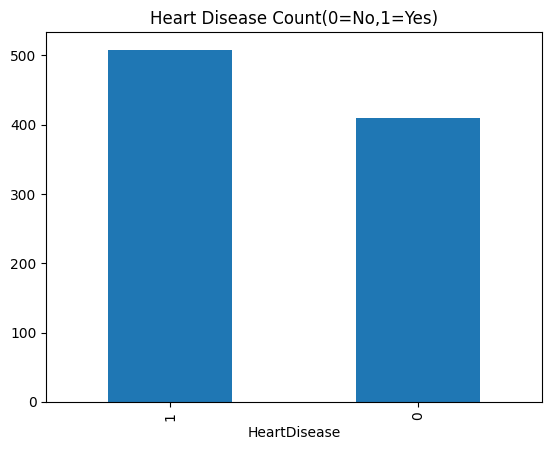

In [8]:
df['HeartDisease'].value_counts().plot(kind='bar')
plt.title('Heart Disease Count(0=No,1=Yes)')
plt.show()



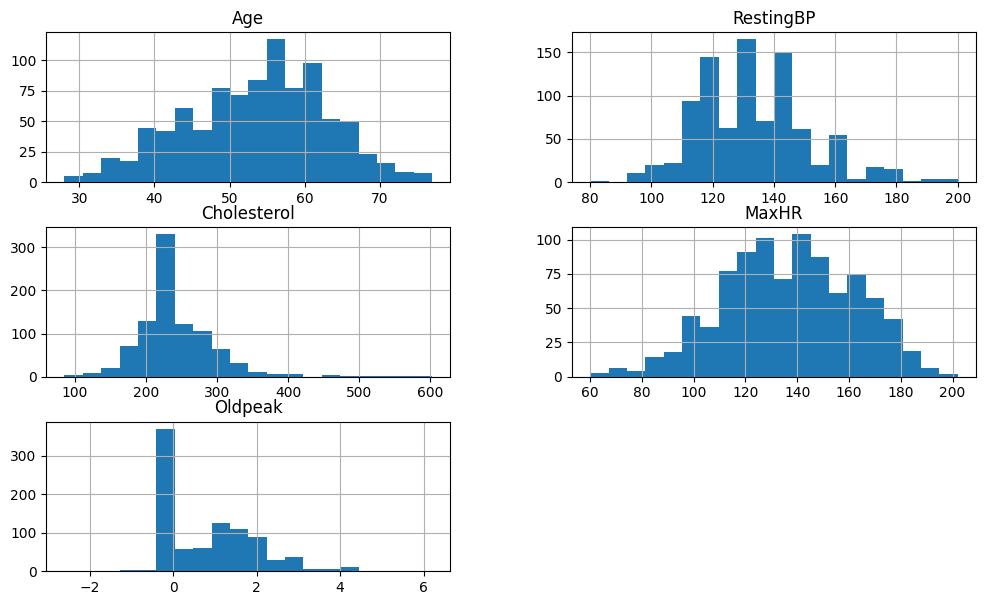

In [9]:
df[['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']].hist(bins=20,figsize=(12,7))
plt.tight_layout
plt.show()

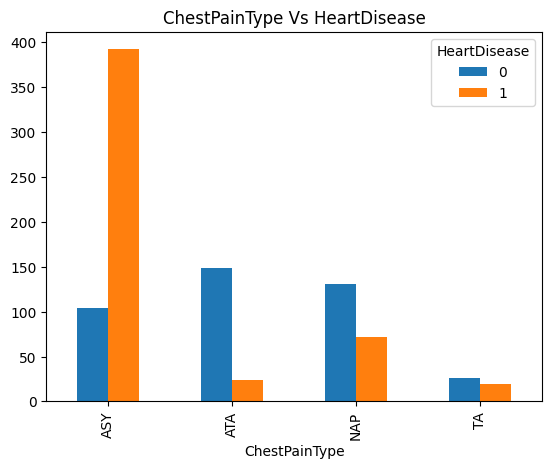

In [10]:
pd.crosstab(df['ChestPainType'],df['HeartDisease']).plot(kind='bar')
plt.title('ChestPainType Vs HeartDisease')
plt.show()

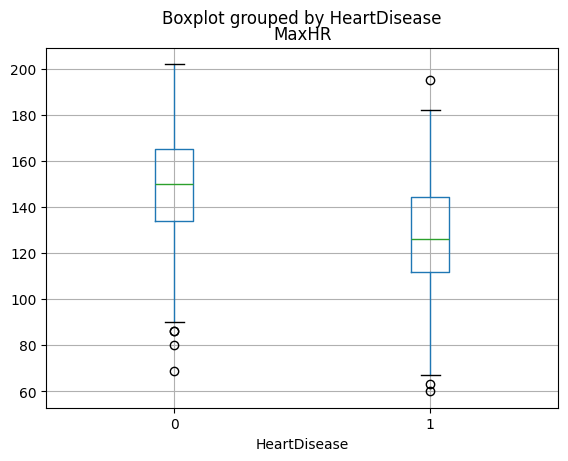

In [11]:
df.boxplot(column='MaxHR',by='HeartDisease')
plt.show()

Convert text columns to number

In [12]:
df=pd.get_dummies(df,columns=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope'],drop_first=True,dtype=int)
df=df.astype(int)

In [13]:
df=df.abs()
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


input (x) and (y)

In [14]:
X=df.drop('HeartDisease',axis=1)
y=df['HeartDisease']

### data preprocessing

Train/test and scaling 

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
y_prob=model.predict_proba(X_test)[:,1]
y_pred_new=(y_prob>=0.3).astype(int)

In [16]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score
print(confusion_matrix(y_test,y_pred_new))
print('accuracy:',round(accuracy_score(y_test,y_pred_new),3))
print('recall(1):',round(recall_score(y_test,y_pred_new),3))


[[64 18]
 [ 6 96]]
accuracy: 0.87
recall(1): 0.941


In [17]:
import joblib
joblib.dump(model,'heart_model.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.to_list(),'columns.pkl')

['columns.pkl']